Reference: https://maartengr.github.io/BERTopic/index.html#installation

In [2690]:
from bertopic import BERTopic
import ssl
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from umap import UMAP
from matplotlib.lines import Line2D

#remove stopwords from the topics list
import nltk
from nltk.corpus import stopwords

# Disable SSL verification - because it is annoying
ssl._create_default_https_context = ssl._create_unverified_context

In [2691]:
# Download stopwords (if not already downloaded)
nltk.download('stopwords')

# Get the English stopwords
stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/priyadcosta/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2692]:
'''
Load the datasets at join them convert the message column into strings. 
'''

df_csop = pd.read_csv('../output/csopII_output_chat_level.csv')
df_jury = pd.read_csv('../output/jury_output_chat_level.csv')

df_csop['message'] = df_csop['message'].astype(str)
df_jury['message'] = df_jury['message'].astype(str)


In [2693]:
'''
Fit the model based on the message column. Each message is a document 
@param
The list of documents/messages we want to fit the model on
'''
def fit_model(documents):
    #umap model initialized to random_state 2 to eliminate stochasticity 
    umap_model = UMAP(n_neighbors=15, n_components=5,min_dist=0.0, metric='cosine', random_state=2)
    model = BERTopic(top_n_words=30,umap_model=umap_model)
    model.fit_transform(documents)
    return model

In [2694]:
'''
Get the top n topics from the model
@param : The BERTopic model, the number of topics we want (This is excluding topic -1)
'''
def get_top_topics(topic_model,n):
    return_list = []
    for i in range(0, n): 
        topic_list = topic_model.get_topic(i)
        return_list.append(topic_list)  
    return return_list  

In [2695]:
'''
Divides the conversation into n equal chunks of time and adds a label for each chunk
@param: The dataframe, the desired number of chunks
'''
def create_chunks(df,num_chunks):
    # Convert timestamp column to DateTime format
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Calculate the total duration of the conversation
    total_duration = (df['timestamp'].max() - df['timestamp'].min()).total_seconds()

    # Calculate the duration of each chunk
    chunk_duration = total_duration / num_chunks

    # Add a new column for chunk number
    df['chunk'] = -1 

    # Assign the chunk number for each row
    for index, row in df.iterrows():

        #get the timestamp 
        timestamp = row['timestamp']

        #calculate the chunk number
        chunk_number = int(((timestamp - df['timestamp'].min())).total_seconds() / chunk_duration)

        #restrict the range of the chunks from 0 to num_chunks - 1
        if chunk_number >= num_chunks:
            df.at[index, 'chunk'] = num_chunks - 1
        else:
            df.at[index, 'chunk'] = chunk_number

In [2696]:
'''
Extract the SBERT Embeddings from the model
'''
def extract_embeddings(model,df):
    embeddings_matrix = model._extract_embeddings(df['message'].tolist())
    return embeddings_matrix

'''
Get the representative docs for a topic and convert it to a df
'''
def get_rep_docs(model,topic_num):
    data = model.get_representative_docs(topic_num)
    df = pd.DataFrame(data,columns=['rep_docs'])
    return df

'''
Vectorize the documents for the topic
'''
def create_bert_vectors(df,on_column):
    docs = df[on_column].tolist()
    sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
    return sentence_model.encode(docs, show_progress_bar=False)

In [2697]:
'''
Get the embeddings for the top topics across the conversation
'''

def get_embeddings_top_topics(df,num_topics):

    #fit the model
    model = fit_model(df['message'].tolist())

    #get the top topics
    top_topics = get_top_topics(model,num_topics)
    
    embeddings_for_top_topics = []
    
    #for each topic
    for j in range(0,len(top_topics)):
        
        #get the representative documents 
        rep_docs_df = get_rep_docs(model,j)

        #create embeddings of the representative documents for each topic
        topic_embeddings = create_bert_vectors(rep_docs_df,'rep_docs')

        embeddings_for_top_topics.append(topic_embeddings) 
        
    return embeddings_for_top_topics

In [2698]:
'''
Get the embeddings for each chunk
'''
def get_embeddings_per_chunk(df,num_chunks):

    chunk_embeddings_list = []

    for i in range(0,num_chunks):
        convo = df[df['chunk'] == i]

        #if the df is empty, i.e there is a pause, create a pseudo 384-dimension embeddings with all values as 0
        if convo.empty:            
            #create n arrays of length 384 (number of dimensions)
            chunk_embeddings = np.zeros((1, 384))

        else:
            chunk_embeddings = create_bert_vectors(convo,'message')
        chunk_embeddings_list.append(chunk_embeddings)
    
    return chunk_embeddings_list

In [2699]:
#rows - every chunk, cols - topics 
def get_similarity(embeddings_per_chunk,embeddings_top_topics):

    topics_per_chunk = []
    for i in range (0,len(embeddings_per_chunk)):
        
        #calculate the cosine similarity for the topic and the chunk
        embeddings = np.mean(embeddings_per_chunk[i], axis=0) #get the average vectors for the chunk(if there are 4 docs, we get the average of 4 docs for each of the 384 dimensions)
        embeddings = np.nan_to_num(embeddings, nan=0) #replace any nan vectors with 0
        embeddings = embeddings.reshape(1, -1) #reshape to a 2D matrix (needed for the cosine similarity function)

        topics = []
        
        # 
        for j in range(0,len(embeddings_top_topics)):
            
            topic = np.mean(embeddings_top_topics[j], axis=0) #get the average vectors for the chunk(if there are 4 docs, we get the average of 4 docs for each of the 384 dimensions)
            topic = np.nan_to_num(topic, nan=0) #replace any nan vectors with 0
            topic = topic.reshape(1, -1) #reshape to a 2D matrix (needed for the cosine similarity function)

            #calculate the cosine similarity betwen the topic embeddings and the chunk embeddings
            cos = cosine_similarity(embeddings,topic)
            topics.append(cos[0][0])

        topics_per_chunk.append(topics)
    
    return topics_per_chunk
    

In [2700]:
'''
Remove the stop words from the topic to visualize the topics better
'''
def create_topics_without_stopwords(top_topics):
    cols = []
    for i in range(0,len(top_topics)):
        filtered_words = [word[0] for word in top_topics[i] if word[0].lower() not in stopwords]
        cols.append(filtered_words)

    topic_list = []
    for i in range(0,len(cols)):
        topic = ""
        for j in range(0,len(cols[i])):
            topic = topic + cols[i][j] +", "

        topic_list.append(topic)
    
    return topic_list

In [2709]:
def plot(df,num_chunks):

    # Set the x-axis tick locations to integers only
    plt.xticks(range(0, num_chunks + 1))

    # Extract the unique topics from the column names. This will extract the topic numbers from 0 to n as strings
    topics = set([col.split(' ')[-1] for col in df.columns])

    lines = []

    #get the list of topics
    for topic in topics:

        # Find columns related to the current topic - e.g. topic 0 in conv0,conv1 etc
        topic_columns = [col for col in df.columns if f'Topic {topic}' in col]

        # Get a color for the current topic
        color = plt.cm.get_cmap('tab10')(int(topic))

        # Plot lines for each column in the current topic
        for column in topic_columns:

            # Plot the line
            line, = plt.plot(df.index, df[column], label=column.split(' ')[0], color=color,alpha=0.5)

            # Get the last index of the DataFrame
            last_index = len(df.index) - 1

            # Get the x and y coordinates for the text label
            x = last_index
            y = df[column].iloc[last_index]

            # Add a text label to the line indicating the conversation number
            plt.text(x, y, f'Convo {column.split(" ")[1]}', color=color, fontsize=10, ha='left', va='bottom')
            lines.append(line)

    # Get the unique colors used in the line graph
    unique_colors = list(set([line.get_color() for line in lines]))

    # create manual tags - NOT THE BEST THING TO DO! NEED TO WORK ON IMPROVING THIS
    manual_tags = ['Topic 1', 'Topic 0']

    # Create custom legend elements
    legend_elements = [Line2D([0], [0], color=color, label=tag) for color, tag in zip(unique_colors, manual_tags)]
    
    # Add the custom legend
    plt.legend(handles=legend_elements)

    # Adding labels and title
    plt.xlabel('Chunk of Time')
    plt.ylabel('Topic Cosine Similarity w.r.t Conversation')
    plt.title('Topics Over Time')

    # Get the current figure
    fig = plt.gcf()

    # Set the new figure size (width, height) in inches
    fig.set_size_inches(8,8)
    
    # Display the chart
    plt.show()

In [2704]:
def plot_topics_over_time(df,num_chunks,num_topics):
    total_convos = df['conversation_num'].max() + 1

    #fit the model
    model = fit_model(df['message'].tolist())

    #reduce the topics. We reduce to num_topics + 1 as there will always be a topic -1 with irrelevant topics
    model.reduce_topics(df['message'].tolist(),num_topics+1)

    #get the topics after reduction
    top_topics = get_top_topics(model,num_topics)

    #get the embeddings for the top topics
    embeddings_top_topics = get_embeddings_top_topics(df,num_topics)

    #remove the stopwords from the topics and recreate the topics without the stopwords
    topic_list = create_topics_without_stopwords(top_topics)

    # #topic per convo as columns: Example: Convo 0 Topic 1
    # columns = []
    # for i in range(0,total_convos):
    #     for j in range(0,len(topic_list)):
    #         col_name = "Convo "+str(i) + " Topic " +str(j)
    #         columns.append(col_name)

    #create an empty df. We will append columns for each Convo-Topic 
    df_for_plotting = None
    
    #iterate through all the conversations (e.g. 347 in Juries)
    for i in range (0,total_convos):
        print("Convo Number " +str(i))

        #filter the df for a specific conversation number
        df_convo = df[df['conversation_num'] == i]

        #create chunks by dividing the conversation into equal units of time
        create_chunks(df_convo,num_chunks)

        #get the embeddings for each chunk
        embeddings_per_chunk = get_embeddings_per_chunk(df_convo,num_chunks)

        #get the similarity between the topic embeddings and the chunk embeddings
        topics_per_chunk = get_similarity(embeddings_per_chunk,embeddings_top_topics)

        #convert the similarity matrix to a dataframe
        topics_df = pd.DataFrame(topics_per_chunk)

        new_column_headings = []

        #column heading for the current conversation. For e.g. 
        # if it is conversation 131 and we have 2 topics, the headings will be Convo 131 Topic 0, Convo 131 Topic 1
        for j in range(0,len(topic_list)):
            col_name = "Convo "+str(i)+" Topic "+str(j)
            new_column_headings.append(col_name)

        if i == 0:#if its the first conversation, we don't need to append the df to an existing df
            df_for_plotting = topics_df
            df_for_plotting.columns = new_column_headings
        else:
            topics_df.columns = new_column_headings
            df_for_plotting = df_for_plotting.join(topics_df)

    #print the top topics
    for i in range(0,len(topic_list)):
        print("Topic " +str(i)+": "+topic_list[i])

    #return the df: rows are the chunks, columns are Convo-Topics
    return df_for_plotting

In [2705]:
df_for_plotting = plot_topics_over_time(df_jury,4,2)

Convo Number 0
Convo Number 1
Convo Number 2
Convo Number 3
Convo Number 4
Convo Number 5
Convo Number 6
Convo Number 7
Convo Number 8
Convo Number 9
Convo Number 10
Convo Number 11
Convo Number 12
Convo Number 13
Convo Number 14
Convo Number 15
Convo Number 16
Convo Number 17
Convo Number 18
Convo Number 19
Convo Number 20
Convo Number 21
Convo Number 22
Convo Number 23
Convo Number 24
Convo Number 25
Convo Number 26
Convo Number 27
Convo Number 28
Convo Number 29
Convo Number 30
Convo Number 31
Convo Number 32
Convo Number 33
Convo Number 34
Convo Number 35
Convo Number 36
Convo Number 37
Convo Number 38
Convo Number 39
Convo Number 40
Convo Number 41
Convo Number 42
Convo Number 43
Convo Number 44
Convo Number 45
Convo Number 46
Convo Number 47
Convo Number 48
Convo Number 49
Convo Number 50
Convo Number 51
Convo Number 52
Convo Number 53
Convo Number 54
Convo Number 55
Convo Number 56
Convo Number 57
Convo Number 58
Convo Number 59
Convo Number 60
Convo Number 61
Convo Number 62
Co

['Convo 0 Topic 0', 'Convo 1 Topic 0', 'Convo 2 Topic 0', 'Convo 3 Topic 0', 'Convo 4 Topic 0', 'Convo 5 Topic 0', 'Convo 6 Topic 0', 'Convo 7 Topic 0', 'Convo 8 Topic 0', 'Convo 9 Topic 0', 'Convo 10 Topic 0', 'Convo 11 Topic 0', 'Convo 12 Topic 0', 'Convo 13 Topic 0', 'Convo 14 Topic 0', 'Convo 15 Topic 0', 'Convo 16 Topic 0', 'Convo 17 Topic 0', 'Convo 18 Topic 0', 'Convo 19 Topic 0', 'Convo 20 Topic 0', 'Convo 21 Topic 0', 'Convo 22 Topic 0', 'Convo 23 Topic 0', 'Convo 24 Topic 0', 'Convo 25 Topic 0', 'Convo 26 Topic 0', 'Convo 27 Topic 0', 'Convo 28 Topic 0', 'Convo 29 Topic 0', 'Convo 30 Topic 0', 'Convo 31 Topic 0', 'Convo 32 Topic 0', 'Convo 33 Topic 0', 'Convo 34 Topic 0', 'Convo 35 Topic 0', 'Convo 36 Topic 0', 'Convo 37 Topic 0', 'Convo 38 Topic 0', 'Convo 39 Topic 0', 'Convo 40 Topic 0', 'Convo 41 Topic 0', 'Convo 42 Topic 0', 'Convo 43 Topic 0', 'Convo 44 Topic 0', 'Convo 45 Topic 0', 'Convo 46 Topic 0', 'Convo 47 Topic 0', 'Convo 48 Topic 0', 'Convo 49 Topic 0', 'Convo 50

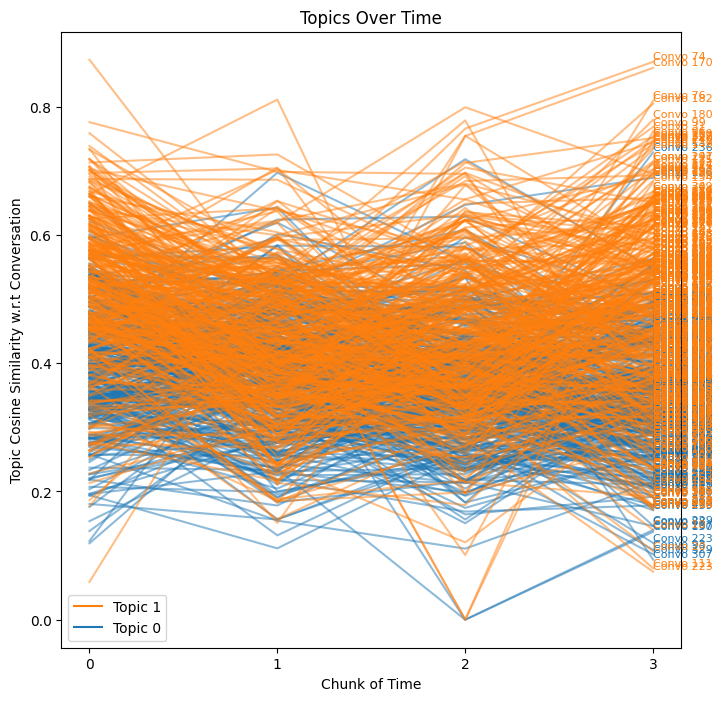

In [2710]:
#plot the entire graph - plotting is kept separate as I am still perfecting it 
plot(df_for_plotting,4)